In [13]:
import matplotlib.pyplot as plt
import pathlib
import numpy as np
from utils import read_im, save_im, normalize
output_dir = pathlib.Path("image_solutions")
output_dir.mkdir(exist_ok=True)

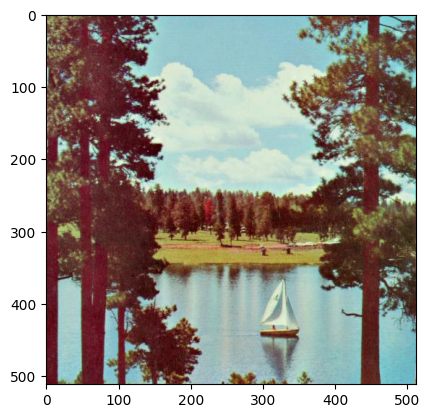

In [14]:
im = read_im(pathlib.Path("images", "lake.jpg"))
plt.imshow(im)

In [15]:
def im_size(img_size: int, kernel_size: int) -> int:
    num_pixels = 0

    for i in range(img_size):
        added = 1 + kernel_size
        if added <= img_size:
            num_pixels += 1
    return num_pixels

In [16]:
def convolve_im(im, kernel,):
    """ A function that convolves im with kernel
    
    Args:
        im ([type]): [np.array of shape [H, W, 3]]
        kernel ([type]): [np.array of shape [K, K]]
    
    Returns:
        [type]: [np.array of shape [H, W, 3]. should be same as im]
    """
    assert len(im.shape) == 3

    # Flip the matrix horizontally then vertically
    kernel = np.flipud(np.fliplr(kernel))

    size = im_size(im.shape[0], kernel.shape[0])

    # Array of zeroes, width and height is the same size for all inputs
    output = np.zeros(shape=(size, size, 3))

    for i in range(3):  # One iterator for each RGB color
        for x in range(size):   # rows
            for y in range(size):   # columns
                # Matrix based on the kernel shape in the input
                mat = im[x:x+kernel.shape[0], y:y+kernel.shape[0], i]

                try:
                    output[x, y, i] = np.sum(np.multiply(mat, kernel))
                except:
                    break
    return output

In [17]:
# Define the convolutional kernels
h_b = 1 / 256  * np.array([
    [1, 4, 6, 4, 1],
    [4, 16, 24, 16, 4],
    [6, 24, 36, 24, 6],
    [4, 16, 24, 16, 4],
    [1, 4, 6, 4, 1]
])
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# Convolve images
im_smoothed = convolve_im(im.copy(), h_b)
save_im(output_dir.joinpath("im_smoothed.jpg"), im_smoothed)
im_sobel = convolve_im(im, sobel_x)
save_im(output_dir.joinpath("im_sobel.jpg"), im_sobel)

# DO NOT CHANGE. Checking that your function returns as expected
assert isinstance(im_smoothed, np.ndarray),     f"Your convolve function has to return a np.array. " +    f"Was: {type(im_smoothed)}"
assert im_smoothed.shape == im.shape,     f"Expected smoothed im ({im_smoothed.shape}" +     f"to have same shape as im ({im.shape})"
assert im_sobel.shape == im.shape,     f"Expected smoothed im ({im_sobel.shape}" +     f"to have same shape as im ({im.shape})"

ValueError: operands could not be broadcast together with shapes (5,4) (5,5) 

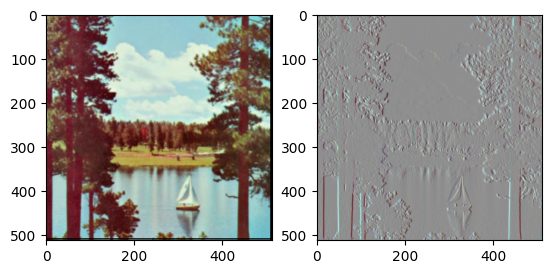

In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(normalize(im_smoothed))

plt.subplot(1, 2, 2)
plt.imshow(normalize(im_sobel))
plt.show()